# 📚 Phishing Email Detection using BERT - Project Notebook

## 📌 Table of Contents

1. [Project Overview](#project-overview)
2. [Environment Setup](#environment-setup)
3. [Data Loading and Sampling](#data-loading-and-sampling)
4. [Exploratory Data Analysis (EDA)](#exploratory-data-analysis-eda)
    - [Label Distribution](#label-distribution)
    - [Text Length Analysis](#text-length-analysis)
    - [Special Characters & URL Analysis](#special-characters--url-analysis)
    - [Top Words in Phishing Emails](#top-words-in-phishing-emails)
5. [Data Preprocessing](#data-preprocessing)
    - [Lowercasing](#lowercasing)
    - [Stopwords Removal (Optional)](#stopwords-removal-optional)
6. [Train-Validation-Test Split (70/10/20)](#train-validation-test-split-701020)
7. [Tokenization using BERT Tokenizer](#tokenization-using-bert-tokenizer)
8. [Dataset Preparation for PyTorch](#dataset-preparation-for-pytorch)
9. [Model Setup with BERT](#model-setup-with-bert)
10. [Define Training Arguments](#define-training-arguments)
11. [Trainer Setup and Metrics](#trainer-setup-and-metrics)
12. [Model Training](#model-training)
13. [Evaluate on Validation Set](#evaluate-on-validation-set)
14. [Evaluate on Test Set](#evaluate-on-test-set)
    - [Accuracy, Precision, Recall, F1-Score](#accuracy-precision-recall-f1-score)
    - [Confusion Matrix](#confusion-matrix)
15. [Plot Metrics (Accuracy/Loss vs Epoch)](#plot-metrics-accuracyloss-vs-epoch)
16. [Saving the Model and Tokenizer](#saving-the-model-and-tokenizer)
17
18. [Load Trained Model for Inference](#load-trained-model-for-inference)
19. [Next Steps and Improvements](#next-steps-and-improvements)


## Project overview
With the rapid rise of AI-generated content, phishing emails have become more sophisticated and harder to detect through traditional methods. Attackers now craft deceptive messages that closely mimic legitimate communication, putting individuals and organizations at risk of data theft, financial fraud, and identity compromise. This project aims to address the growing threat by developing an intelligent phishing email detection system using BERT, a powerful transformer-based language model. By analyzing the textual content of emails, our model learns to distinguish between phishing and legitimate messages with high accuracy, helping to automate and enhance email security on a large scale.

In [3]:
import pandas as pd
import re
import torch

#libraries for data explore
import seaborn as sns
import matplotlib.pyplot as plt

#libraries for Model training and evaluation
from sklearn.model_selection import train_test_split
from transformers import BertTokenizer, BertForSequenceClassification
from transformers import Trainer, TrainingArguments
from transformers import DataCollatorWithPadding
from datasets import Dataset
from sklearn.metrics import accuracy_score, precision_recall_fscore_support


In [7]:
import zipfile

# Define the path to the zip file and the desired output directory
zip_file_path = "/content/phishing_email.csv.zip"
extract_path = "/content/"

# Unzip the file
with zipfile.ZipFile(zip_file_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

# Example: Load a CSV dataset
df = pd.read_csv("/content/phishing_email.csv")

df.shape

(82486, 2)

In [8]:
# Randomly sample 15,000 rows from the full dataset
df = df.sample(n=15000, random_state=42).reset_index(drop=True)

print(df.head())

                                       text_combined  label
0  endangered languages workshop foundation endan...      0
1  claretta claretta_bordersfusemailcom cialis wo...      1
2  roger upole schkeramsncom kyle rickey wrote im...      0
3  barclays customer service testlightworldcojp d...      1
4  gmm 09 nov 2001 please find attached global ma...      0


# Explore the dataset

#### Plot Class Distribution

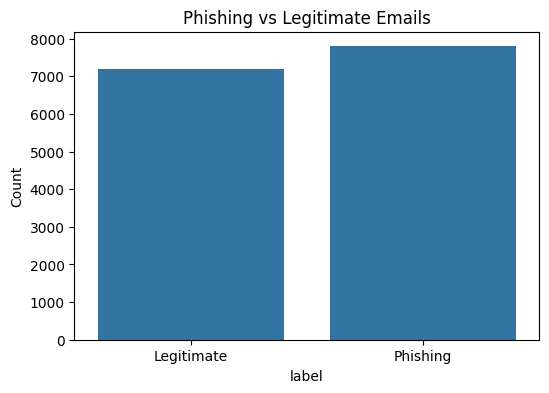

In [9]:
plt.figure(figsize=(6,4))
sns.countplot(data=df, x='label') # counts the number of occurrences of each unique value in a column
plt.title('Phishing vs Legitimate Emails')
plt.xticks([0, 1], ['Legitimate', 'Phishing'])
plt.ylabel('Count')
plt.show()


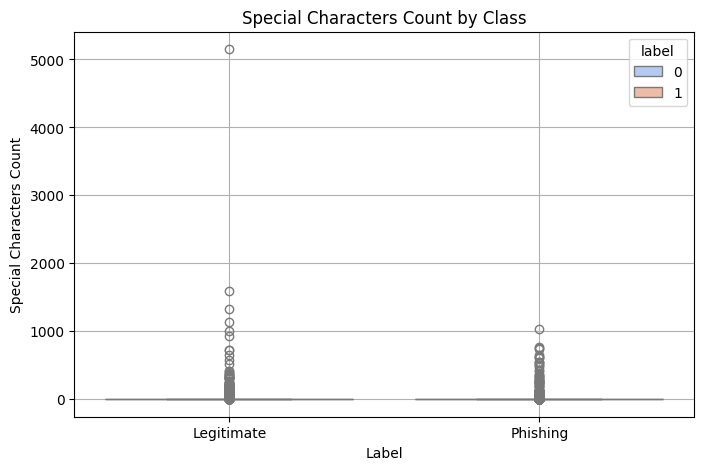

In [11]:
df['special_chars'] = df['text_combined'].apply(lambda x: sum(not c.isalnum() and not c.isspace() for c in x))

plt.figure(figsize=(8,5))
sns.boxplot(x='label', y='special_chars', data=df, hue='label', palette='coolwarm', dodge=False)

plt.xticks([0, 1], ['Legitimate', 'Phishing'])
plt.title('Special Characters Count by Class')
plt.xlabel('Label')
plt.ylabel('Special Characters Count')
plt.grid(True)
plt.show()

#### Most Common Words

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


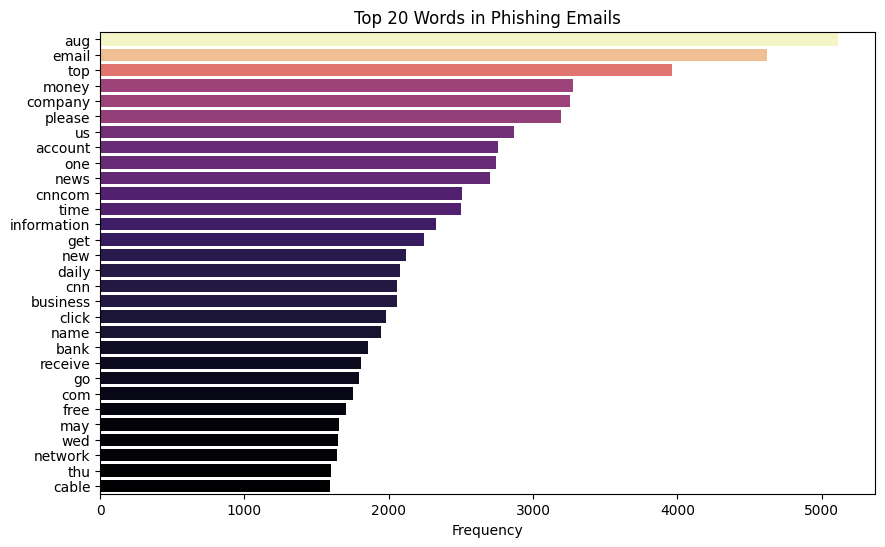

In [15]:
from collections import Counter
import nltk
from nltk.corpus import stopwords
nltk.download('stopwords')


stop_words = set(stopwords.words('english'))  #e.g., "the", "is", "and"

# Combine all phishing emails: Joins all texts into one string → converts to lowercase → splits into words
phishing_words = ' '.join(df[df['label']==1]['text_combined']).lower().split() #Selects only phishing emails (where label == 1)

filtered_words = [word for word in phishing_words if word.isalpha() and word not in stop_words] #Alphabetic words (removes numbers, punctuation)

word_freq = Counter(filtered_words).most_common(30)

# Barplot of top words
words, counts = zip(*word_freq)  #Unpacks the 20 most common word–count pairs into two separate lists: words and counts
plt.figure(figsize=(10,6))
sns.barplot(x=list(counts), y=list(words),hue =list(counts), palette='magma',legend=False)
plt.title('Top 20 Words in Phishing Emails')
plt.xlabel('Frequency')
plt.show()

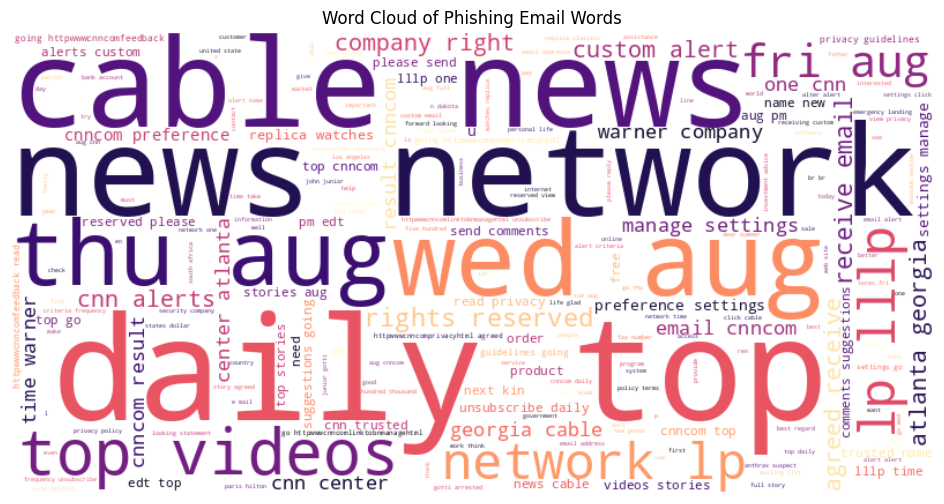

In [16]:
from wordcloud import WordCloud

# Join all filtered phishing words into a single string
wordcloud_text = ' '.join(filtered_words)

# Generate word cloud
wordcloud = WordCloud(width=800, height=400, background_color='white', colormap='magma').generate(wordcloud_text)

# Display the word cloud
plt.figure(figsize=(12, 6))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Word Cloud of Phishing Email Words')
plt.show()


 ### Split the Dataset in training , validation and test

In [18]:
from sklearn.model_selection import train_test_split

# 1. First, split out 20% test data

train_val_texts, test_texts, train_val_labels, test_labels = train_test_split(df['text_combined'].tolist(), df['label'].tolist(), test_size=0.2, random_state=42, stratify=df['label'])

# 2. Then split remaining 80% into 70% train and 10% val

train_texts, val_texts, train_labels, val_labels = train_test_split(
    train_val_texts, train_val_labels,
    test_size=0.125,  # 10% of total = 12.5% of the remaining 80%
    random_state=42, stratify=train_val_labels
)

#### Tokenization using BERT Tokenizer

These encodings are the tokenized versions of your input texts, structured in a way that BERT can understand

In [19]:
tokenizer = BertTokenizer.from_pretrained("bert-base-uncased")

# Tokenize the datasets
train_encodings = tokenizer(train_texts, truncation=True, padding=True)
val_encodings = tokenizer(val_texts, truncation=True, padding=True)


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

In [20]:
print(train_encodings['input_ids'][0])          # View input IDs of the first text
print(train_encodings['attention_mask'][0])

[101, 17264, 7027, 2373, 3001, 3204, 3283, 2218, 3116, 5395, 3288, 2362, 3001, 3136, 3293, 2111, 3625, 12697, 2311, 17264, 7027, 3001, 2763, 3174, 2111, 2164, 7014, 2566, 12624, 4938, 2154, 7113, 7014, 10439, 14511, 2080, 3960, 2534, 8886, 17891, 6746, 6927, 3902, 3762, 6754, 24185, 21007, 2063, 7369, 2014, 19333, 6264, 6606, 3889, 14085, 5076, 20105, 16215, 6072, 2050, 5297, 11623, 2928, 27078, 8512, 6519, 10524, 2116, 2048, 17817, 4484, 3116, 2034, 3154, 9129, 2111, 2551, 9033, 10483, 7014, 2177, 3225, 2831, 4938, 2177, 2609, 6337, 2136, 3931, 20105, 9352, 26351, 2014, 19333, 25212, 2015, 4372, 2050, 3043, 2264, 4372, 2050, 2225, 4372, 2050, 3872, 2968, 19387, 2080, 7617, 2111, 3331, 2028, 2178, 2117, 3154, 6343, 2699, 4949, 4072, 4972, 4906, 2362, 13487, 6927, 3902, 3762, 28762, 8925, 6746, 5247, 3204, 3331, 2177, 5059, 3861, 3001, 2499, 4906, 2362, 2716, 3232, 2111, 9669, 5397, 6509, 2622, 2373, 8400, 8312, 5491, 9556, 2052, 8627, 2298, 5530, 2340, 2321, 7680, 7849, 4697, 3314, 114

In [21]:
class EmailDataset(torch.utils.data.Dataset):
    def __init__(self, encodings, labels):
        self.encodings = encodings
        self.labels = labels

    def __getitem__(self, idx):
        item = {k: torch.tensor(v[idx]) for k, v in self.encodings.items()}
        item['labels'] = torch.tensor(self.labels[idx])
        return item

    def __len__(self):
        return len(self.labels)

train_dataset = EmailDataset(train_encodings, train_labels)
val_dataset = EmailDataset(val_encodings, val_labels)


#### Load Pretrained BERT for Classification

In [ ]:
model = BertForSequenceClassification.from_pretrained("bert-base-uncased", num_labels=2)


#### Define Evaluation Metrics

In [22]:
def compute_metrics(pred):
    labels = pred.label_ids
    preds = pred.predictions.argmax(-1)
    precision, recall, f1, _ = precision_recall_fscore_support(labels, preds, average='binary')
    acc = accuracy_score(labels, preds)
    return {
        'accuracy': acc,
        'f1': f1,
        'precision': precision,
        'recall': recall
    }


#### Training Arguments

`TrainingArguments` is a configuration class that defines how your model should be trained. You pass it key training parameters such as:

- `output_dir`: Where to save model checkpoints.
- `learning_rate`: Controls how fast the model learns.
- `num_train_epochs`: Number of complete passes through the training data.
- `evaluation_strategy`: When to run validation (e.g., `"epoch"` means after every epoch).
- `per_device_train_batch_size`: Batch size per GPU/CPU device during training.
- `logging_dir`: Directory to store training logs.

It does **not** train the model — it only stores training settings that the `Trainer` will use.



In [23]:
training_args = TrainingArguments(
    output_dir='./results',
    eval_strategy="epoch",       # Validates after each epoch
    save_strategy="epoch",             # Saves checkpoint after each epoch
    save_total_limit=2,                # Keep only last 2 checkpoints
    learning_rate=2e-5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    num_train_epochs=5,
    weight_decay=0.01,
    optim="adamw_torch",
    logging_dir='./logs',
    logging_strategy="epoch",          # Log once per epoch
    load_best_model_at_end=True,       # Optional: load best val score model
    metric_for_best_model="f1",        # Based on compute_metrics
    greater_is_better=True             # Because higher F1 is better
)


`logging_dir` is deprecated and will be removed in v5.2. Please set `TENSORBOARD_LOGGING_DIR` instead.


In [30]:
model = BertForSequenceClassification.from_pretrained("bert-base-uncased", num_labels=2)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    data_collator=DataCollatorWithPadding(tokenizer=tokenizer),
    compute_metrics=compute_metrics
)

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [30]:
from transformers import BertForSequenceClassification, Trainer, TrainingArguments, DataCollatorWithPadding
import torch # Added import for EmailDataset
from transformers import BertTokenizer # Added import for tokenizer
from sklearn.model_selection import train_test_split # Added import for train_test_split

# 1. First, split out 20% test data
# Assumes df is already defined from previous cells
train_val_texts, test_texts, train_val_labels, test_labels = train_test_split(df['text_combined'].tolist(), df['label'].tolist(), test_size=0.2, random_state=42, stratify=df['label'])

# 2. Then split remaining 80% into 70% train and 10% val
train_texts, val_texts, train_labels, val_labels = train_test_split(
    train_val_texts, train_val_labels,
    test_size=0.125,  # 10% of total = 12.5% of the remaining 80%
    random_state=42, stratify=train_val_labels
)

# Define training arguments within the cell to ensure it's always available
training_args = TrainingArguments(
    output_dir='./results',
    eval_strategy="epoch",       # Validates after each epoch
    save_strategy="epoch",             # Saves checkpoint after each epoch
    save_total_limit=2,                # Keep only last 2 checkpoints
    learning_rate=2e-5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    num_train_epochs=5,
    weight_decay=0.01,
    optim="adamw_torch",
    logging_dir='./logs',
    logging_strategy="epoch",          # Log once per epoch
    load_best_model_at_end=True,       # Optional: load best val score model
    metric_for_best_model="f1",        # Based on compute_metrics
    greater_is_better=True             # Because higher F1 is better
)

# EmailDataset class definition
class EmailDataset(torch.utils.data.Dataset):
    def __init__(self, encodings, labels):
        self.encodings = encodings
        self.labels = labels

    def __getitem__(self, idx):
        item = {k: torch.tensor(v[idx]) for k, v in self.encodings.items()}
        item['labels'] = torch.tensor(self.labels[idx])
        return item

    def __len__(self):
        return len(self.labels)

# Initialize tokenizer
tokenizer = BertTokenizer.from_pretrained("bert-base-uncased")

# Tokenize the datasets
train_encodings = tokenizer(train_texts, truncation=True, padding=True)
val_encodings = tokenizer(val_texts, truncation=True, padding=True)

train_dataset = EmailDataset(train_encodings, train_labels)
val_dataset = EmailDataset(val_encodings, val_labels)

model = BertForSequenceClassification.from_pretrained("bert-base-uncased", num_labels=2)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    data_collator=DataCollatorWithPadding(tokenizer=tokenizer),
    compute_metrics=compute_metrics
)

# Ensure trainer is defined, then run training
trainer.train()

NameError: name 'df' is not defined

## Plot Accuracy and Loss vs Epoch

In [31]:
import matplotlib.pyplot as plt

# Extract logs
log_history = trainer.state.log_history

# Gather data
train_loss = [entry['loss'] for entry in log_history if 'loss' in entry]
eval_loss = [entry['eval_loss'] for entry in log_history if 'eval_loss' in entry]
eval_acc  = [entry['eval_accuracy'] for entry in log_history if 'eval_accuracy' in entry]
epochs = list(range(1, len(eval_loss)+1))

# Plot loss
plt.figure(figsize=(10,4))
plt.subplot(1, 2, 1)
plt.plot(epochs, train_loss, label='Training Loss')
plt.plot(epochs, eval_loss, label='Validation Loss')
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Loss over Epochs")
plt.legend()

# Plot accuracy
plt.subplot(1, 2, 2)
plt.plot(epochs, eval_acc, marker='o', color='green', label='Validation Accuracy')
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Validation Accuracy over Epochs")
plt.legend()

plt.tight_layout()
plt.show()


NameError: name 'trainer' is not defined

In [11]:
from google.colab import drive
drive.mount('/content/drive')

MessageError: Error: credential propagation was unsuccessful

## Save the Final Model & Tokenizer

In [ ]:
# Save model and tokenizer
model.save_pretrained("./final_model")
tokenizer.save_pretrained("./final_model")


In [ ]:
from transformers import BertForSequenceClassification, BertTokenizer
model = BertForSequenceClassification.from_pretrained("./final_model")
tokenizer = BertTokenizer.from_pretrained("./final_model")


### Test the model

##### Tokenize test data

In [ ]:
test_encodings = tokenizer(test_texts, truncation=True, padding=True)

#### Convert to PyTorch Dataset

In [ ]:
test_dataset = EmailDataset(test_encodings, test_labels)

#### Evaluate Model on Test Set

In [20]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Run predictions on the test set
test_results = trainer.predict(test_dataset)

# Extract predicted class labels
y_pred = test_results.predictions.argmax(axis=1)
y_true = test_labels  # Make sure test_labels is a list of integers

# Print all core metrics
print("Final Test Evaluation Metrics:\n")
print("Accuracy       :", accuracy_score(y_true, y_pred))
print("Precision      :", precision_score(y_true, y_pred))
print("Recall         :", recall_score(y_true, y_pred))
print("F1 Score       :", f1_score(y_true, y_pred))
print("\nClassification Report:\n", classification_report(y_true, y_pred, target_names=["Legitimate", "Phishing"]))



NameError: name 'trainer' is not defined

In [21]:
# Plot confusion matrix
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Legitimate', 'Phishing'], yticklabels=['Legitimate', 'Phishing'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix - Test Set')
plt.tight_layout()
plt.show()


NameError: name 'y_true' is not defined

In [22]:
from sklearn.metrics import classification_report

y_pred = test_results.predictions.argmax(axis=1)
print(classification_report(test_labels, y_pred, target_names=["Legitimate", "Phishing"]))


NameError: name 'test_results' is not defined